In [1]:
!pip install kaggle

In [2]:
import json

kaggle_token = {
    "username": "leonesgaston",
    "key": "KGAT_0f346219c64c7522b05875b3fe60425b"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_token, f)

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets list

ref                                                         title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                              Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000          10960        238                1  
nalisha/job-salary-prediction-dataset                       Job Salary Prediction Dataset                          3144815  2026-03-16 19:54:33.843000          14937        330                1  
rosemeenshaikh/op-rated-tv-shows-from-tmdb                  Top Rated TV Shows from TMDB                            335625  2026-04-20 09:10:56.430000            601         27                1  
mubashirsidiki/stude

In [5]:
!kaggle datasets download -d moltean/fruits

Dataset URL: https://www.kaggle.com/datasets/moltean/fruits
License(s): CC-BY-SA-4.0
100% 5.45G/5.45G [01:03<00:00, 92.7MB/s]



In [6]:
!unzip fruits.zip

Se han truncado las últimas 5000 líneas del flujo de salida.
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Raspberry 3/r0_17.jpg  
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Raspberry 3/r0_173.jpg  
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Raspberry 3/r0_177.jpg  
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Raspberry 3/r0_181.jpg  
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Raspberry 3/r0_185.jpg  
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Raspberry 3/r0_189.jpg  
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Raspberry 3/r0_193.jpg  
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Raspberry 3/r0_197.jpg  
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Raspberry 3/r0_201.jpg  
  inflating: fruits-360_original-size/fruits-360-

In [7]:
import os
print(os.listdir('fruits-360_100x100/fruits-360'))

['Training', 'README.md', 'LICENSE', 'Test']


In [8]:
import os
import shutil

base_original = 'fruits-360_100x100/fruits-360'
base_new = 'fruits_subset'

# Elegimos solo 10 clases
selected_classes = os.listdir(f'{base_original}/Training')[:10]

for split in ['Training', 'Test']:
    for cls in selected_classes:
        src = f'{base_original}/{split}/{cls}'
        dst = f'{base_new}/{split}/{cls}'
        os.makedirs(dst, exist_ok=True)

        # copiamos máximo 200 imágenes por clase
        for file in os.listdir(src)[:200]:
            shutil.copy(os.path.join(src, file), dst)

In [9]:
print(os.listdir('fruits_subset/Training'))

['Cherry 4', 'Cherry Wax 1', 'Quince 1', 'Tomato Cherry Red 2', 'Tomato 1', 'Papaya 2', 'Grape Pink 1', 'Potato Sweet 1', 'Onion Red 3', 'Pepper 2']


In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (100, 100)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    'fruits_subset/Training',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    'fruits_subset/Training',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset='validation'
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    'fruits_subset/Test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 1600 images belonging to 10 classes.
Found 400 images belonging to 10 classes.
Found 1693 images belonging to 10 classes.


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model_a = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(100,100,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])

model_a.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
history_a = model_a.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)


Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 40s 740ms/step - accuracy: 0.5362 - loss: 1.2182 - val_accuracy: 0.9450 - val_loss: 0.3123
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 40s 730ms/step - accuracy: 0.8675 - loss: 0.3844 - val_accuracy: 0.9475 - val_loss: 0.1322
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 38s 752ms/step - accuracy: 0.9431 - loss: 0.1674 - val_accuracy: 0.9675 - val_loss: 0.0799
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 38s 761ms/step - accuracy: 0.9388 - loss: 0.1753 - val_accuracy: 0.9850 - val_loss: 0.0609
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 38s 760ms/step - accuracy: 0.9756 - loss: 0.0850 - val_accuracy: 1.0000 - val_loss: 0.0068
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 36s 729ms/step - accuracy: 0.9756 - loss: 0.0727 - val_accuracy: 0.9975 - val_loss: 0.0067
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 38s 761ms/step - accuracy: 0.9794 - loss: 0.0645 - val_accuracy: 1.0000 - val_loss: 0.0090
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 46s 920ms/step - accuracy: 0.9781 - loss: 0.0734 - val_accu

In [13]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense

base_model = MobileNetV2(
    input_shape=(100,100,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # congelamos

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model_b = Model(inputs=base_model.input, outputs=output)

model_b.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/tmp/ipykernel_21488/4063588391.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
history_b = model_b.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 31s 509ms/step - accuracy: 0.9187 - loss: 0.2928 - val_accuracy: 0.9975 - val_loss: 0.0149
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 453ms/step - accuracy: 0.9969 - loss: 0.0156 - val_accuracy: 1.0000 - val_loss: 0.0063
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 447ms/step - accuracy: 0.9956 - loss: 0.0137 - val_accuracy: 0.9975 - val_loss: 0.0049
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 429ms/step - accuracy: 0.9981 - loss: 0.0111 - val_accuracy: 0.9975 - val_loss: 0.0063
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 456ms/step - accuracy: 0.9994 - loss: 0.0025 - val_accuracy: 1.0000 - val_loss: 0.0026
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 26s 514ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 9.1094e-04
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 426ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 0.9975 - val_loss: 0.0088
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 454ms/step - accuracy: 1.0000 - loss: 0.0010 - val_

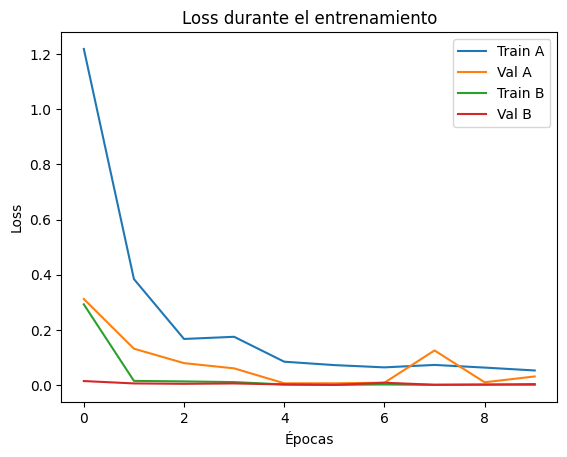

In [15]:
import matplotlib.pyplot as plt

plt.plot(history_a.history['loss'], label='Train A')
plt.plot(history_a.history['val_loss'], label='Val A')

plt.plot(history_b.history['loss'], label='Train B')
plt.plot(history_b.history['val_loss'], label='Val B')

plt.title('Loss durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [16]:
loss_a, acc_a = model_a.evaluate(test_generator)
print("Test Accuracy Modelo A:", acc_a)

loss_b, acc_b = model_b.evaluate(test_generator)
print("Test Accuracy Modelo B:", acc_b)

53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 197ms/step - accuracy: 1.0000 - loss: 0.0069
Test Accuracy Modelo A: 1.0
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 278ms/step - accuracy: 0.9994 - loss: 0.0057
Test Accuracy Modelo B: 0.9994093179702759


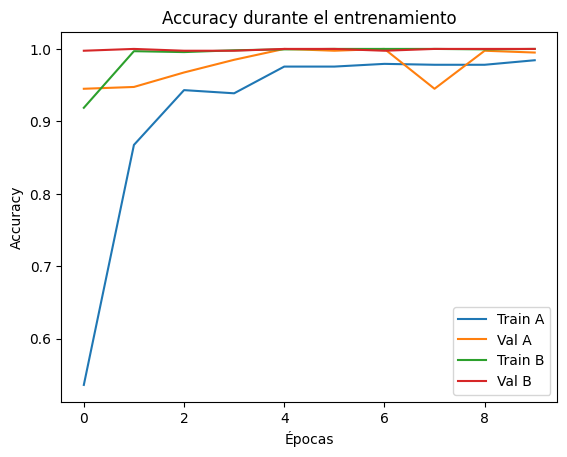

In [17]:
plt.plot(history_a.history['accuracy'], label='Train A')
plt.plot(history_a.history['val_accuracy'], label='Val A')

plt.plot(history_b.history['accuracy'], label='Train B')
plt.plot(history_b.history['val_accuracy'], label='Val B')

plt.title('Accuracy durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 384ms/step


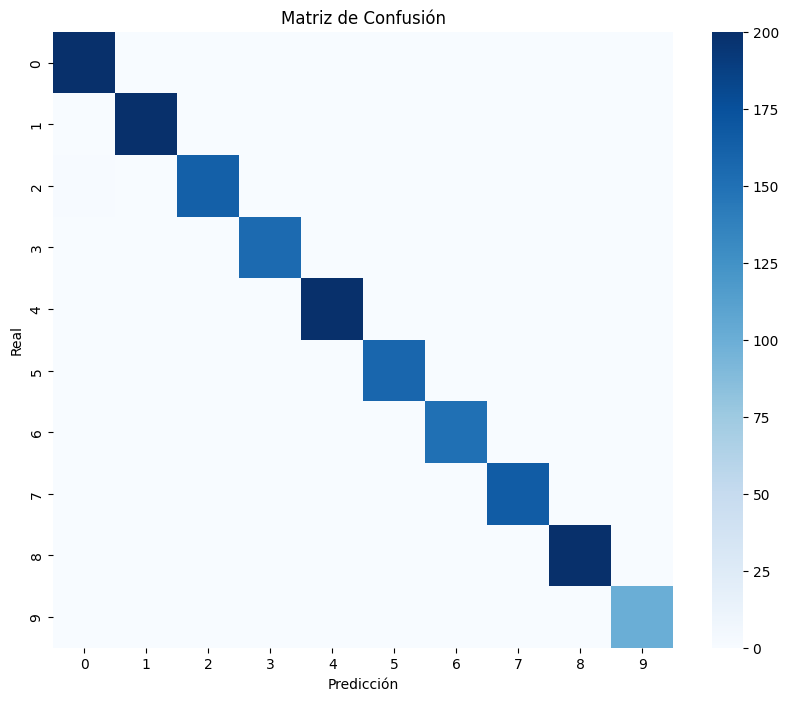

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_pred = model_b.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(test_generator.classes, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

***Datos del dataset***

Dataset utilizado: https://www.kaggle.com/datasets/moltean/fruits

Tipo de problema: Clasificación de imágenes multiclase, donde el objetivo es identificar el tipo de fruta a partir de una imagen.

Cantidad de clases: Se utilizaron 10 clases seleccionadas del dataset original.

Cantidad de imágenes por clase: 200 imágenes por clase en el conjunto de entrenamiento

**¿Qué clase fue la más difícil de clasificar y por qué?**
Las clases más difíciles fueron aquellas visualmente similares, como diferentes tipos de tomates. Esto se debe a que comparten características visuales muy parecidas, lo que dificulta la discriminación por parte del modelo.

**¿Detectaron overfitting? ¿Cómo?**
Se observó un leve overfitting en el Modelo B, donde la precisión de entrenamiento alcanzó el 100% mientras que la validación presentó pequeñas caídas en algunas épocas. Esto indica que el modelo comienza a ajustarse demasiado a los datos de entrenamiento.

**¿Qué impacto tuvo el data augmentation?**
El data augmentation ayudó a mejorar la generalización del modelo, evitando que aprenda patrones demasiado específicos del dataset. Esto contribuyó a mantener alta la precisión en validación y test.

**¿Por qué el transfer learning suele funcionar mejor con pocos datos?**
Porque los modelos preentrenados ya han aprendido características generales (bordes, texturas, formas) a partir de grandes datasets. Esto permite reutilizar ese conocimiento y adaptarlo a nuevos problemas con menos datos.

**Si quisieran llevar este modelo a producción, ¿qué revisarían antes?**
Antes de llevar el modelo a producción se debería:

- Evaluar con datos reales (no controlados)
- Analizar robustez ante cambios de iluminación o fondo
- Optimizar el modelo para rendimiento (latencia)
- Validar con más clases y datos diversos
- Evitar overfitting